11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testinag images : (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.8660 - loss: 0.4694 - val_accuracy: 0.9768 - val_loss: 0.0819
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.9759 - loss: 0.0850 - val_accuracy: 0.9828 - val_loss: 0.0615
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.9848 - loss: 0.0514 - val_accuracy: 0.9865 - val_loss: 0.0520
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.9893 - loss: 0.0349 - val_accuracy: 0.9865 - val_loss: 0.0526
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 0.9917 - loss: 0.0279 - val_accuracy: 0.9880 - val_loss: 0.0524
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9816 - loss: 0.0578
Test Accuracy: 0.9854000210762024


Saving 7.png to 7.png


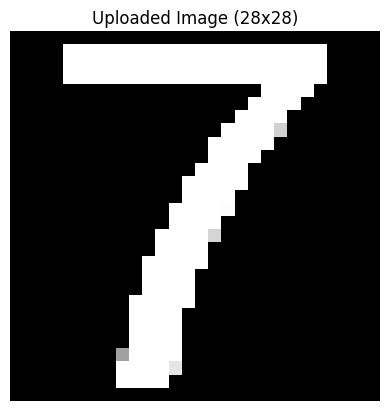

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Digit: 1


In [1]:
#Introduction to Dl for Image classification

import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from google.colab import files

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testinag images :", X_test.shape)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    img_resized = cv2.resize(img_gray, (28, 28))
    img_resized = 255 - img_resized
    img_resized = img_resized / 255.0

    img_input = img_resized.reshape(1, 28, 28, 1)

    plt.imshow(img_resized, cmap='gray')
    plt.title("Uploaded Image (28x28)")
    plt.axis('off')
    plt.show()

    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    print("Predicted Digit:", predicted_digit)